<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/Copy_of_06_Assignment_survival_analysis_all_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPM 204 Assignment: Survival Analysis

### Instructions
1. For all questions, output should be displayed in the notebook. If working together, give credit to the contributing member. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
2. DO NOT BLINDLY COPY CODE; use of AI Chatbot, while discouraged is allowed. Using Chatbots drastically reduce understanding especially when learning new code or techniques, see [Wu & Yu 2023](https://doi.org/10.1111/bjet.13334) and [Abbas et al. 2024](https://doi.org/10.1186/s41239-024-00444-7). If you plan to use Chatbots, use them to understand bits of code and the technique under study, do not use them to do coding for you.
3. Additionally, please provide the colab notebook after adding the necessary segments and code chunks along with the outputs.
4. To answer text-based (non-code) questions, use a text chunk. It can be created by hovering over the previous chunk and clicking on `+Text` or clicking on `+Text` on the left top corner of your command bar.

Total maximum points =
 - Part 0:  0
 - Part 1:  5
 - Part 2:  5
 - Part 3:  10 + 2 (bonus)
 - Part 4:  5
 - Part 5:  5 + 1 (bonus)
 - **Total max:   30**


# Part 0
Load the `surv_cow.csv` data into the Colab workspace and read into R workspace in this notebook. Load/ install required packages:
 - `survival`
 - `survminer`
 - `ggplot2`
The dataset contains the following columns:
1. `$cowID`: Unique cow identifier
2. `$birth_date`: Birth_date in yyyy-mm-dd
3. `$scc`: Observed Somatic Cell Count ÷ 1000
4. `$obs_date`: Observation date in yyyy-mm-dd
5. `$daily_milk`: Observed milk production in pounds (lb)
6. `$event`: Event variable (binary 0/1)
7. `$lactation`: Number of lactations
**NOTE: The dataset will be available on canvas or distributed during the lecture on survival analysis. If the dataset is not available, reach out before proceeding with this assignment.**

In [1]:
install.packages("survival")
install.packages("survminer")
library(survival)
library(survminer)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘litedown’, ‘corrplot’, ‘car’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘mvtnorm’, ‘gridtext’, ‘ggpubr’, ‘gridExtra’, ‘maxstat’, ‘ggtext’


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [2]:
surv_cow <- read.csv("surv_cow.csv")

# Part 1 (points: 5)

Summarize the dataset and answer the following questions: (max points for questions = 4)
1. Which variables are categorical and which are continuous? (1)
2. Which variables are potentially independent variables/ explanatory variables? (0.5)
3. How many cows do our dataset represent? (0.5)
4. The `surv_cow$event` is the event variable. What does the 0 and 1 values represent? [Hint: Read censoring and truncation] (1)
5. How many missing values in `$scc` and `$daily_milk` respectively? Are they missing at random or is their a possible reason why they are missing? (1)

[Hint: `table(is.na(surv_cow$scc), surv_cow$_____)`]

ANSWERS:

1) Categorical: cowID, event, lactation

    Continuous: scc, daily_milk, birth_date, obs_date

2) Potential independent variables: daily_milk, lactation, scc, event

3) 20 cows

4) With the event varaible, 0 means the event did not occur, and 1 means the event occurred.

5) Missing values for scc are 89 and $daily_milk are 89. They are not missing at random because they both fall in the 0 columns after running the code. If there were random, they would be more scattered across column 0 and 1.

In [3]:
# complete this code chunk for Part 1 (0.5 points)
summary(surv_cow)
str(surv_cow)

     cowID           birth_date       scc              obs_date  
 Min.   : 1.00   Length   :320   Min.   : 130.0   Length   :320  
 1st Qu.: 5.75   N.unique : 14   1st Qu.: 493.5   N.unique :302  
 Median :10.50   N.blank  :  0   Median : 878.0   N.blank  :  0  
 Mean   :10.50   Min.nchar: 10   Mean   : 989.5   Min.nchar: 10  
 3rd Qu.:15.25   Max.nchar: 10   3rd Qu.:1187.5   Max.nchar: 10  
 Max.   :20.00                   Max.   :5872.0                  
                                 NAs    :89                      
   daily_milk         event          lactation    
 Min.   : 40.14   Min.   :0.0000   Min.   :0.000  
 1st Qu.: 93.40   1st Qu.:0.0000   1st Qu.:0.000  
 Median :120.93   Median :0.0000   Median :2.000  
 Mean   :150.73   Mean   :0.0625   Mean   :2.166  
 3rd Qu.:180.32   3rd Qu.:0.0000   3rd Qu.:3.250  
 Max.   :720.71   Max.   :1.0000   Max.   :7.000  
 NAs    :89                                       

'data.frame':	320 obs. of  7 variables:
 $ cowID     : int  1 1 1 1 1 1 1 1 1 1 ...
 $ birth_date: chr  "2015-02-27" "2015-02-27" "2015-02-27" "2015-02-27" ...
 $ scc       : int  NA NA NA 1852 3091 1669 1090 1982 993 438 ...
 $ obs_date  : chr  "2015-08-30" "2016-02-23" "2016-06-01" "2017-05-27" ...
 $ daily_milk: num  NA NA NA 394 204 ...
 $ event     : int  0 0 0 0 0 0 0 0 0 0 ...
 $ lactation : int  0 0 0 1 1 1 2 2 3 4 ...


In [4]:
table(is.na(surv_cow$scc),        surv_cow$event)
table(is.na(surv_cow$daily_milk),  surv_cow$event)

       
          0   1
  FALSE 211  20
  TRUE   89   0

       
          0   1
  FALSE 211  20
  TRUE   89   0

In [5]:
# complete this code chunk for Part 1 (0.5 points)
surv_cow$birth_date <- as.Date(surv_cow$birth_date, format = "%Y-%m-%d")
surv_cow$obs_date   <- as.Date(surv_cow$obs_date,   format = "%Y-%m-%d")

# surv_time = how long the cow was observed = age at observation
surv_cow$surv_time  <- surv_cow$obs_date - surv_cow$birth_date

surv_cow$lactation  <- as.factor(surv_cow$lactation)

# Drop rows with missing values in ANY column
surv_cow <- surv_cow[complete.cases(surv_cow), ]

head(surv_cow)

,cowID,birth_date,scc,obs_date,daily_milk,event,lactation,surv_time
,<int>,<date>,<int>,<date>,<dbl>,<int>,<fct>,<drtn>
4,1,2015-02-27,1852,2017-05-27,393.7690,0,1,820 days
5,1,2015-02-27,3091,2017-08-22,204.4032,0,1,907 days
6,1,2015-02-27,1669,2017-12-13,284.1972,0,1,1020 days
7,1,2015-02-27,1090,2018-11-04,258.6040,0,2,1346 days
8,1,2015-02-27,1982,2019-02-10,179.6753,0,2,1444 days
9,1,2015-02-27,993,2020-03-24,186.9644,0,3,1852 days


In [6]:
#how many cows represented in dataset
length(unique(surv_cow$cowID))

[1] 20

# Part 2 (points: 5)
In this section you need to create the survival object or `Surv() object` and plot the Kaplan-Meier's curves

Answer the following questions (max points = 3):
1. What are the basic two components necessary for creating a survival object? (1)
2. What is the time component in our dataframe? (0.5)
3. Is our survival objected right-censored/ left-censored/ left-truncated/ right-truncated? (1) [Hint: read censoring and truncation]
4. Roughly at what minimum age do cows start having an event? (0.5) [Hint: Look at plots generated in code chunks below]

ANSWERS:

1) Time and Event are the basic components necessary for creating a survival object.

2) Cows age in days

3) Right-censored as some cows were still alive at the end of the study period and were culled sometime after the last observation. In the KM plot, we see the curve starting at 1 where everyone is alive, and then drops to the right with censored obsevataions marked along the curve, meaning they were still alive at their last obsevation.

4) At about 2000 days of age, cows begin to have events.

In [7]:
# Complete the following code chunk (1 point)
# Create the survival object — combines time (how long observed) and event (did culling occur)
surv_obj <- Surv(time = surv_cow$surv_time, event = surv_cow$event)

In [8]:
# Plot the Kaplan - Meier Curve(0.5 point)
# Fit a baseline Kaplan-Meier curve with no predictors (~1 means intercept only)
km_basic <- survfit(surv_obj ~ 1, data = surv_cow)

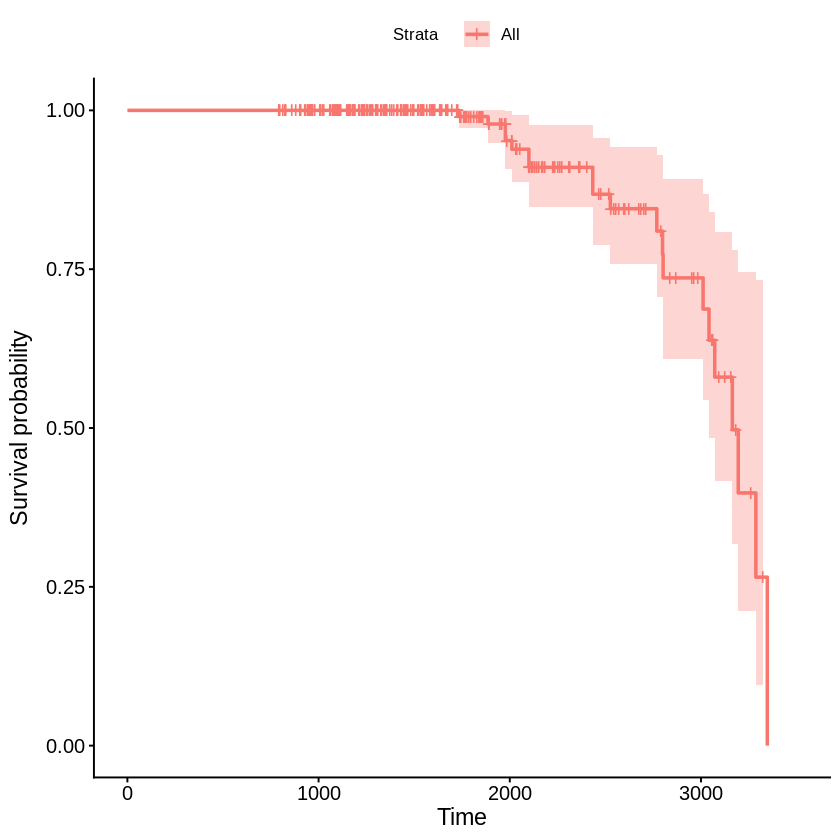

In [9]:
# Plot the event distribution of KM curve (0 points)
# Plot the Kaplan-Meier survival curve
ggsurvplot(km_basic, data = surv_cow)

# Part 3 (points: 10)
In this part you will have to fit non and semi-parametric survival models:
1. non-parametric survival analysis
2. Cox Proportional Hazards


ANSWER:
I was not able to compare KM models because KM is a non-parametirc method, as it does not assum any distribution or estimate a likelihood function. Both anova and AIC require a likelihood to calculate, which cannot be applied with this code. KM models can only be compared visually in plots.

## KM non-parametric analysis

In [11]:
# Complete this code chunk (2 points)
#fitting KM survival model with different predictors
surv_mod0 <- survfit(surv_obj ~ 1,                                    data = surv_cow)
surv_mod1 <- survfit(surv_obj ~ daily_milk,                           data = surv_cow)
surv_mod2 <- survfit(surv_obj ~ scc + daily_milk,                     data = surv_cow)
surv_mod3 <- survfit(surv_obj ~ scc + daily_milk + strata(lactation), data = surv_cow)

In [12]:
# Give all model summaries
summary(surv_mod0)
summary(surv_mod1)
summary(surv_mod2)
summary(surv_mod3)

Call: survfit(formula = surv_obj ~ 1, data = surv_cow)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
 1734    103       1    0.990 0.00966       0.9715        1.000
 1886     84       1    0.979 0.01512       0.9493        1.000
 1977     75       2    0.952 0.02341       0.9076        0.999
 2011     70       1    0.939 0.02673       0.8878        0.993
 2100     66       2    0.910 0.03263       0.8486        0.977
 2434     43       2    0.868 0.04269       0.7882        0.956
 2526     38       1    0.845 0.04728       0.7574        0.943
 2769     24       1    0.810 0.05694       0.7057        0.930
 2799     22       1    0.773 0.06517       0.6554        0.912
 2802     21       1    0.736 0.07172       0.6084        0.891
 3011     15       1    0.687 0.08203       0.5439        0.868
 3042     14       1    0.638 0.08967       0.4845        0.840
 3072     11       1    0.580 0.09851       0.4159        0.809
 3164      7       1    0.497 0.11409       0.31

Call: survfit(formula = surv_obj ~ daily_milk, data = surv_cow)

                daily_milk=40.1354161498602 
        time       n.risk      n.event     survival      std.err lower 95% CI 
        1977            1            1            0          NaN           NA 
upper 95% CI 
          NA 

                daily_milk=49.0837161720265 
        time       n.risk      n.event     survival      std.err lower 95% CI 
        3042            1            1            0          NaN           NA 
upper 95% CI 
          NA 

                daily_milk=53.690194869414 
        time       n.risk      n.event     survival      std.err lower 95% CI 
        2100            1            1            0          NaN           NA 
upper 95% CI 
          NA 

                daily_milk=61.1325405953595 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                daily_milk=61.1422611176968 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

            

Call: survfit(formula = surv_obj ~ scc + daily_milk, data = surv_cow)

                scc=130, daily_milk=109.307605809031 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=145, daily_milk=83.3309862669557 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=173, daily_milk=113.483668166834 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=177, daily_milk=196.398886547734 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=182, daily_milk=120.93289103492  
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=182, daily_milk=122.884192784938 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=193, daily_milk=190.525965305666 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=196, daily_milk=74.8647913398842 
     time n.ri

Call: survfit(formula = surv_obj ~ scc + daily_milk + strata(lactation), 
    data = surv_cow)

                scc=130, daily_milk=109.307605809031, strata(lactation)=2 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=145, daily_milk=83.3309862669557, strata(lactation)=2 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=173, daily_milk=113.483668166834, strata(lactation)=3 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=177, daily_milk=196.398886547734, strata(lactation)=1 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=182, daily_milk=120.93289103492 , strata(lactation)=3 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=182, daily_milk=122.884192784938, strata(lactation)=4 
     time n.risk n.event survival std.err lower 95% CI upper 95% CI

                scc=193, daily_milk=190.

In [13]:
# Compare models; is it possible to use the following functions?
# Can we compare KM models with anova and AIC?
anova(surv_mod0, surv_mod1)
AIC(surv_mod0)

ERROR: Error in UseMethod("anova"): no applicable method for 'anova' applied to an object of class "survfit"


In [ ]:
# Plotting (1 point; 2 bonus points)
ggsurvplot(surv_mod0, data = __________,risk.table = T, conf.int = T,_______)
# also display (i) median survival time and probability, (ii) cumulative events--
# --(iii) and censoring in this model

 For bonus points plot cumulative hazards with cumulative events using ggsurvplot and explain the relationship between median survival probability of cows in our dataset and baseline hazards of `surv_mod0` (2 sentences max; +2)

 ANSWER:

 The cumulative hazard stays near zero until about 2000 days, showing that cows have a low risk of being culled early on. As the cumulative hazard rises steeply after 2000 days, the survival proability drops, with the median survival time occurring when half of all cows have been culled.

Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"


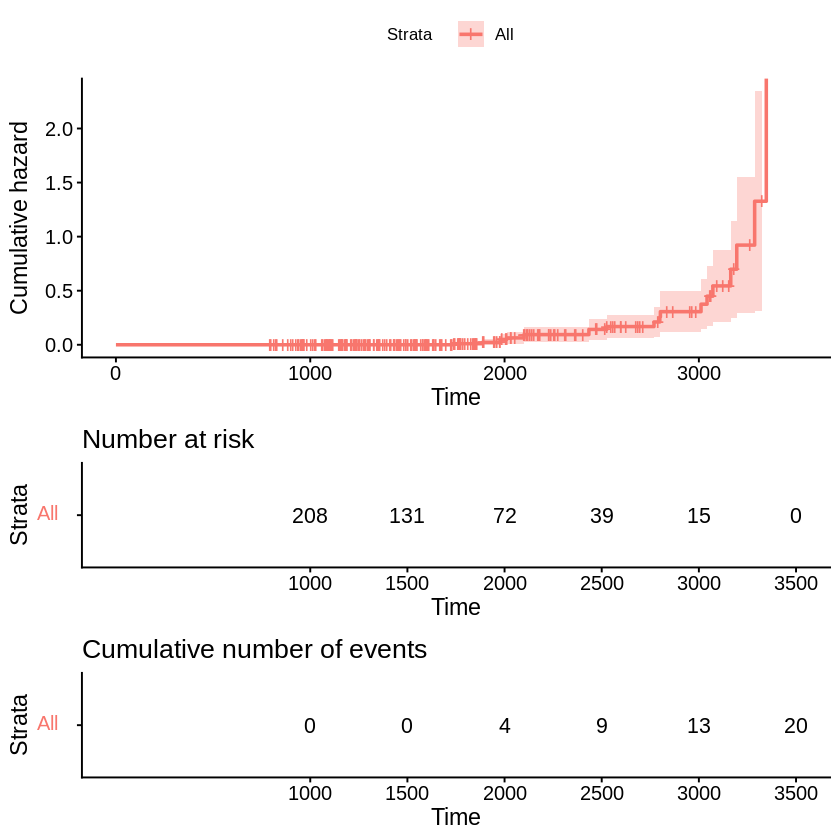

In [14]:
# Plot cumulative hazard with cumulative events for surv_mod0
ggsurvplot(
  surv_mod0,
  data     = surv_cow,
  fun      = "cumhaz",    # switches to cumulative hazard instead of survival
  risk.table = TRUE,
  cumevents  = TRUE
)

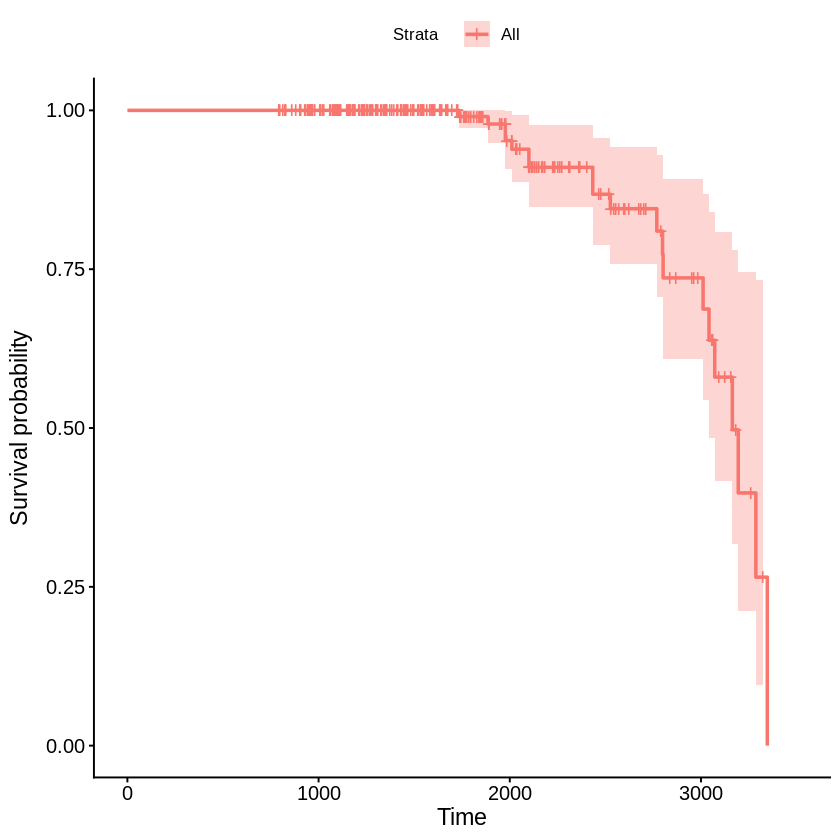

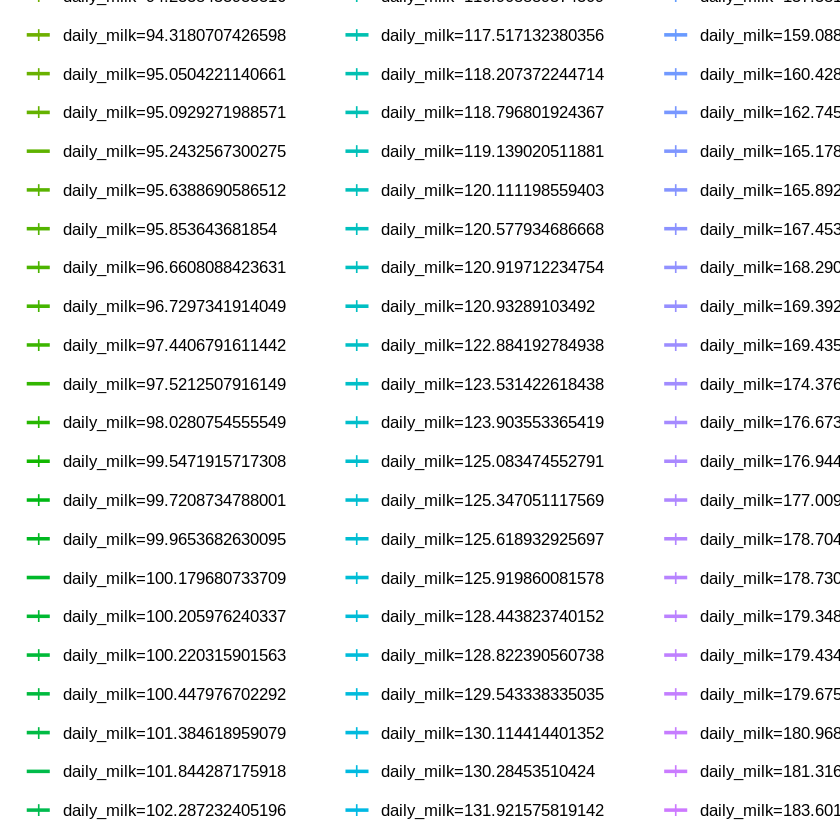

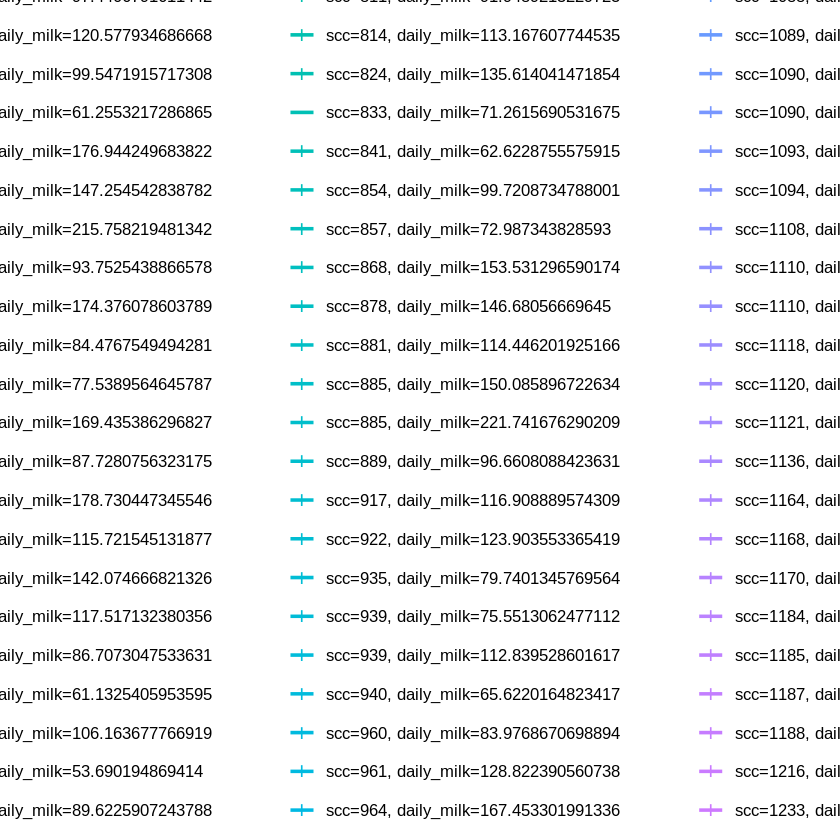

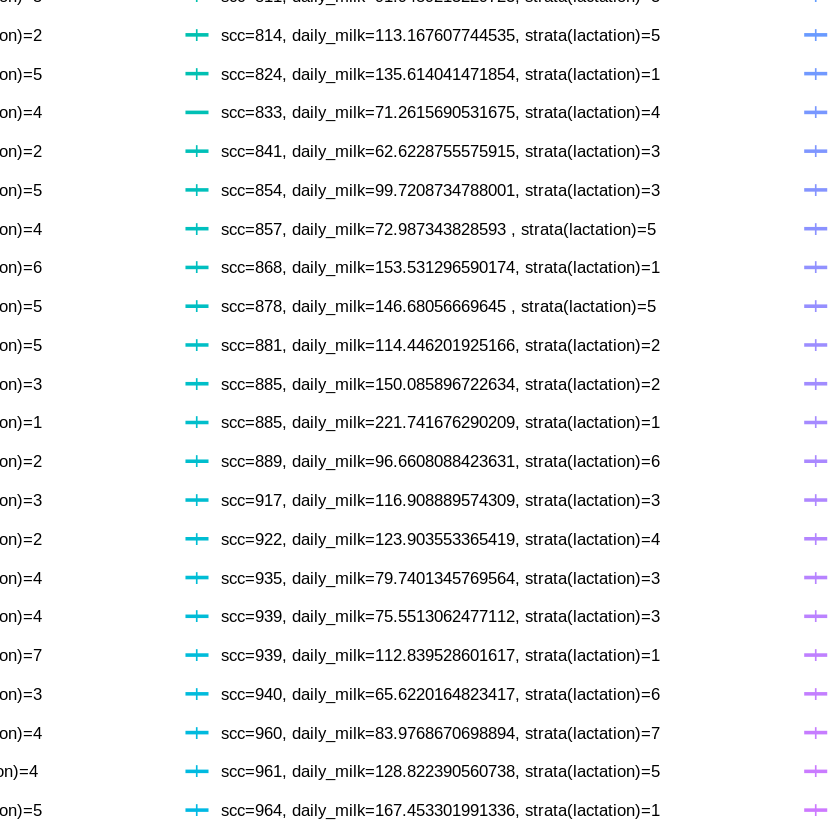

In [16]:
# Plot each model to compare
ggsurvplot(surv_mod0, data = surv_cow)
ggsurvplot(surv_mod1, data = surv_cow)
ggsurvplot(surv_mod2, data = surv_cow)
ggsurvplot(surv_mod3, data = surv_cow)

Answer the following questions for Part 3 (max points for questions = 2)
1. Which of the models is the best fit? Why? (1)
2. Is 1it better to fit lactation as a strata or as a variable? Why? (1) [Justify with code and output]

ANSWER:

1) Models surv_mod1, surv_mod2, and surv_mod3 are uninterpretable because scc and daily_milk are continuous variables, creating hundreds of curves. Therefore surv_mod0 is the best fitting because it shows the overall survival of all cows.

2) It is better to fit lactation as strata because lactation is time-dependent, since it increases as the cow ages during the study. Using strata(lactation) allows separate baseline survival curves for each lactation group rahter than forcing a coefficient, which better accounts for lactation over time.

## Cox-Proportional Hazards model

In [18]:
# Fit Cox PH models with increasing complexity
ph_mod0 <- coxph(surv_obj ~ 1, data = surv_cow)
ph_mod1 <- coxph(surv_obj ~ scc + daily_milk + strata(lactation), data = surv_cow)
ph_mod2 <- coxph(surv_obj ~ scc + daily_milk, data = surv_cow, weights = as.numeric(surv_cow$lactation))

In [19]:
# Compare Cox models using AIC
AIC(ph_mod0, ph_mod1, ph_mod2)

,df,AIC
,<dbl>,<dbl>
ph_mod0,0,126.29735
ph_mod1,2,90.14315
ph_mod2,2,1205.43065


In [20]:
summary(ph_mod1)

Call:
coxph(formula = surv_obj ~ scc + daily_milk + strata(lactation), 
    data = surv_cow)

  n= 231, number of events= 20 

                 coef  exp(coef)   se(coef)      z Pr(>|z|)  
scc        -0.0002028  0.9997972  0.0008857 -0.229   0.8189  
daily_milk -0.0254318  0.9748888  0.0112431 -2.262   0.0237 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

           exp(coef) exp(-coef) lower .95 upper .95
scc           0.9998      1.000    0.9981    1.0015
daily_milk    0.9749      1.026    0.9536    0.9966

Concordance= 0.692  (se = 0.075 )
Likelihood ratio test= 6.42  on 2 df,   p=0.04
Wald test            = 5.24  on 2 df,   p=0.07
Score (logrank) test = 5.38  on 2 df,   p=0.07


Answer the following questions (max points for questions = 3)
1. Which of the cox models is the best fit? Justify with code and output (1)
2. What is the difference between `ph_mod1` and `ph_mod2`? (1.5)
3. What is the interpretation of the estimated `coef` and `exp(coef)` in the model summary? (1.5)

ANSWER:

1) ph_mod1 is thebest fit, because it has the lowest AIC of 90.14. This inlcudes scc, daily_milk, and strata(lactation), accointing for both predictors while allowing separate baseline hazards for each lactation group.

2) ph_mod1 includes strata(lactation), allowing for separate basline survival curves for each lactation group. ph_mod2 instead uses weights which makes cows in higher lactation groups contribute more to the model fitting.

3) Coeff is the log hazard ratio on the log scale. exp(ceof) is the hazard ratio (HR), which is the one we use to interprete. for scc, exp(corf) = 0.9998 meaning SCC has almost no effect on culling hazard. Daily_milk exp(coef)=0.9749 which means each additional pound of milk prodcued decreases the hazard of culling by about 2.5%.

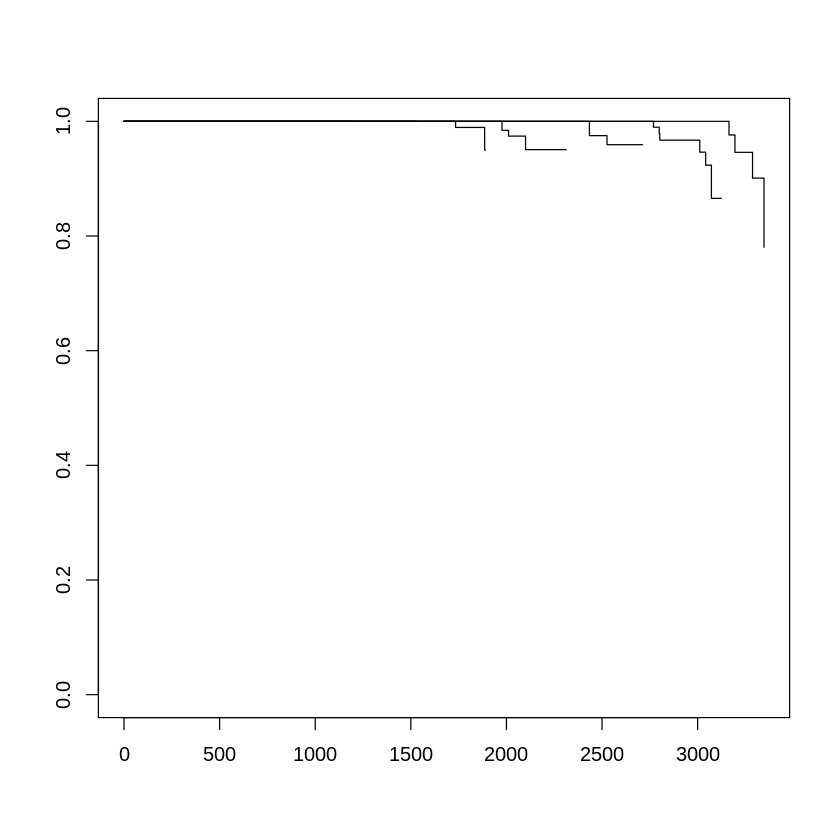

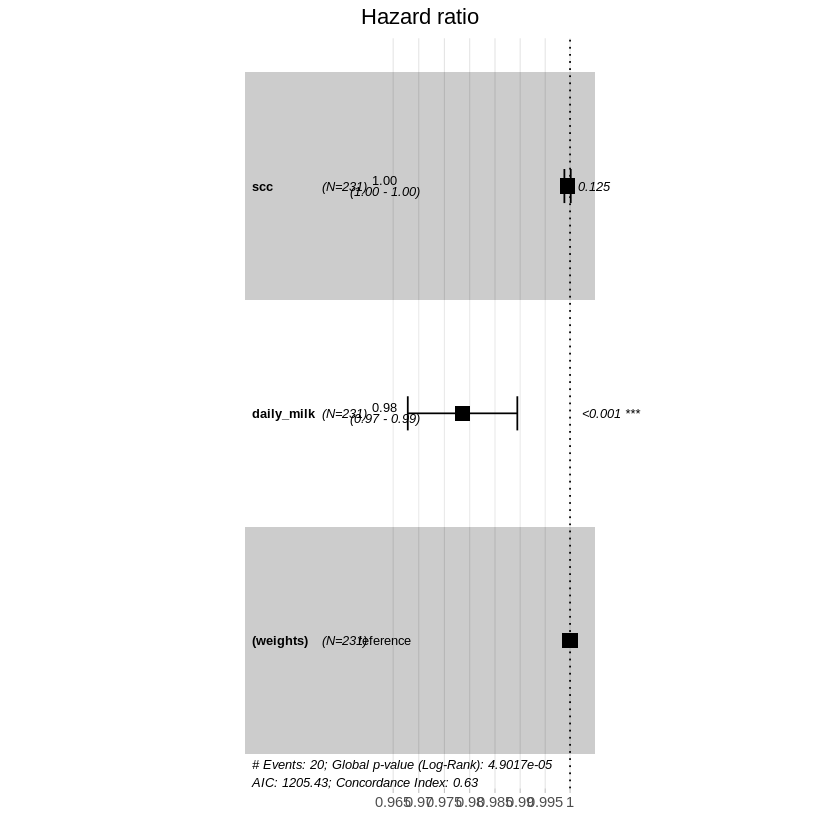

In [27]:
# Plot the outcomes of the models using ggadjustedcurves() and ggforest()
# Plot survival curves directly from the model
plot(survfit(ph_mod1, data = surv_cow))

# Plot forest plot
# Forest plot using ph_mod2 (no strata)
ggforest(ph_mod2, data = surv_cow)

### Diagnostics (1 point)
Complete the following code chunk and answer the following:
1. For our best fitting model, does the assumptions of proportional hazard hold? If yes, why? if not, why not?
2. Plot the diagnostic test outcomes using either `plot(cox.zph())` or `ggcoxdiagnostics()`

ANSWER:

1) the proporational hazards assumption hold for ph_mod1 because scc p-value is 0.81, and daily_milk p-value is 0.14, both greater than 0.05 in the cox.zph test. This indiicztes the hazard ratio does not significantly change over time.


            chisq df    p
scc        0.0583  1 0.81
daily_milk 2.2173  1 0.14
GLOBAL     2.3275  2 0.31


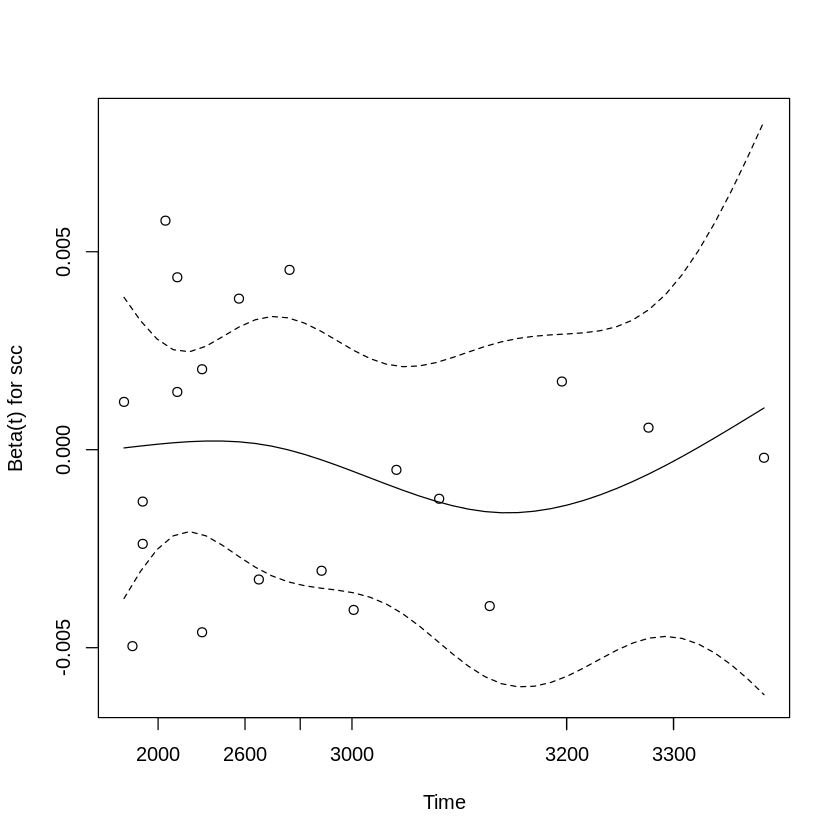

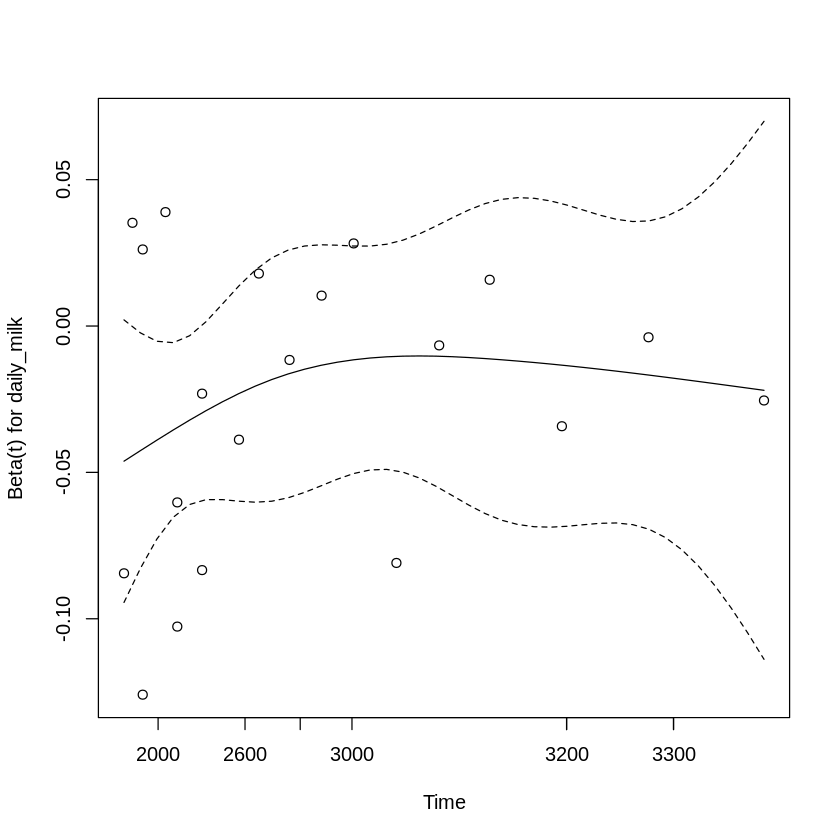

In [28]:
# code chunk for question 2
# Test the proportional hazards assumption
ph_zph <- cox.zph(ph_mod1)
print(ph_zph)

# Plot the Schoenfeld residuals
plot(ph_zph)

Call: survfit(formula = ph_mod2, newdata = new_data)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
 1734    570       4    0.997 0.00182        0.993        1.000
 1886    494       4    0.993 0.00293        0.987        0.999
 1977    453      10    0.983 0.00555        0.972        0.994
 2011    428       5    0.977 0.00681        0.964        0.991
 2100    408      10    0.966 0.00931        0.948        0.984
 2434    290      12    0.948 0.01332        0.923        0.975
 2526    260       6    0.939 0.01537        0.909        0.969
 2769    176       7    0.924 0.01894        0.887        0.962
 2799    162       7    0.908 0.02259        0.865        0.954
 2802    155       7    0.892 0.02622        0.842        0.945
 3011    113       7    0.870 0.03124        0.811        0.933
 3042    106       7    0.847 0.03621        0.779        0.921
 3072     85       7    0.817 0.04194        0.739        0.903
 3164     56       8    0.771 0.05107        0.677

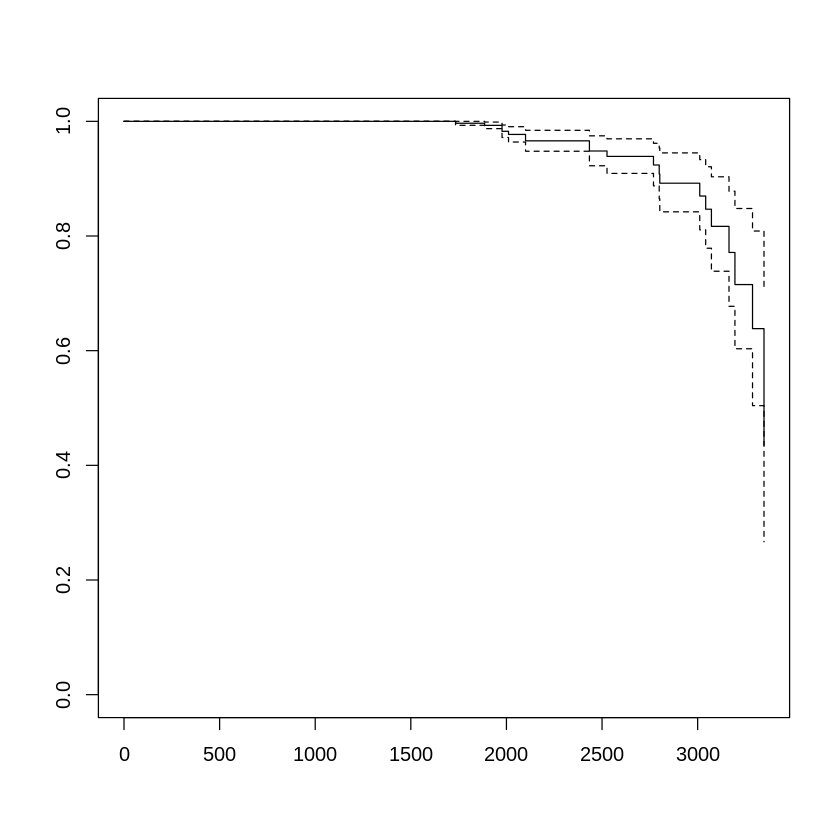

In [29]:
# Create new data with median predictor values for prediction
new_data <- data.frame(
  scc        = median(surv_cow$scc,        na.rm = TRUE),
  daily_milk = median(surv_cow$daily_milk, na.rm = TRUE)
)

# Generate survival predictions from ph_mod2
pred <- survfit(ph_mod2, newdata = new_data)
summary(pred)
plot(pred)

# Part 4 (points: 5)

Answer the following questions:
1. Based on all the previous analyses in this assignment, which variables explain the survival probabilities of the cows in the datasets? (1)
2. Which survival analysis technique will you choose for studying this type of data? Why? [Explain in 3-4 sentences] (2)
3. If we decide to use the model `ph_mod2`as our final model (might not be the best model), how can we determine the time for future events occuring? [code and output needed with 2-3 sentence explanation] (2)

ANSWERS:

1) daily_milk is the variable that best explains the survival probabilites of cows in this dataset. It was statistiically signficant in the cox PH model, with higher daily milk production associated with a lower hazard of being culled. Scc was not significant.

2) Cox proportional hazards is the most apprpriate because the assumption was confirmed using cox.zph with all p-values grater than 0.05 and flat schoenfeld residual plots. It walso doesnt require assuming specific ditribution for surivival times, making it more flexible. Also, it allows us to estimate hazard ratios for predictors like daily_milk which has significant influence to cow survival.

3) using survfit() on oh_mod2 with edian values of scc and daily_milk we can generate predcited survival probabilites at each point time. The summary table shows predicted survival probability dropping beow 0.5  after 3000 days, meaning the median predicted time to clling for a sow with median milk production and scc is about 3000 days. The plot visualized the predicted survival curve.

# Part 5 (points: 5)
## Parametric Models (PH and AFT)

 - PH: Using Weibull and exponential distributions
 - AFT: Using Lognormal Distribution



In [30]:
# use survreg function for fitting a weibull and exponential model with daily_milk as the independent variable
# 0.5 points
# Fit Weibull model with daily_milk as predictor
para_mod1 <- survreg(surv_obj ~ daily_milk, data = surv_cow,
                     dist = "weibull",
                     weights = as.numeric(surv_cow$lactation))

# Fit exponential model with daily_milk as predictor
para_mod2 <- survreg(surv_obj ~ daily_milk,
                     dist = "exponential",
                     data = surv_cow,
                     weights = as.numeric(surv_cow$lactation))

summary(para_mod1)
summary(para_mod2)

Warning message in survreg.fit(X, Y, weights, offset, init = init, controlvals = control, :
“Ran out of iterations and did not converge”



Call:
survreg(formula = surv_obj ~ daily_milk, data = surv_cow, weights = as.numeric(surv_cow$lactation), 
    dist = "weibull")
                Value Std. Error    z      p
(Intercept)  8.36e+00   1.11e-02  754 <2e-16
daily_milk  -2.85e-03   1.74e-05 -164 <2e-16
Log(scale)  -2.24e+00   0.00e+00 -Inf <2e-16

Scale= 0.107 

Weibull distribution
Loglik(model)= -1588.1   Loglik(intercept only)= -1075.7
	Chisq= -1024.82 on 1 degrees of freedom, p= 1 
Number of Newton-Raphson Iterations: 30 
n= 231 



Call:
survreg(formula = surv_obj ~ daily_milk, data = surv_cow, weights = as.numeric(surv_cow$lactation), 
    dist = "exponential")
              Value Std. Error     z       p
(Intercept) 6.62128    0.34765 19.05 < 2e-16
daily_milk  0.03180    0.00409  7.77 7.8e-15

Scale fixed at 1 

Exponential distribution
Loglik(model)= -1279   Loglik(intercept only)= -1326.5
	Chisq= 95.02 on 1 degrees of freedom, p= 1.9e-22 
Number of Newton-Raphson Iterations: 7 
n= 231 


In [31]:
# Compare two models (0.5 point)
# Compare models
anova(para_mod1, para_mod2)
AIC(para_mod1, para_mod2)


,Terms,Resid. Df,-2*LL,Test,Df,Deviance,Pr(>Chi)
,<chr>,<int>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,daily_milk,228,3176.281,,NA,NA,NA
2,daily_milk,229,2558.033,=,-1,618.2477,NA


,df,AIC
,<dbl>,<dbl>
para_mod1,3,3182.281
para_mod2,2,2562.033


Answer the following questions (2.5 points)
1. Which model is better fitted? Why? (1)
2. Interpret the `value` column in the summary. What does it mean? Explain the `value` of the `(Intercept)` and the `daily_milk`. How do the `value` differ from the `coef` of cox PH model in Part 3? (1.5)

ANSWERS:

1) para_mod2 is the better fit model having a lower AIC compared to para_mod1. Also, para_mod1 (Weibull) failed to converge.

2) Value column represents effect of each predictor on log survival time. The intercept of 6.621 means the basline survival time is exp(6.621) days. Each additional poundo f daily_milk multiplies survival time by exp(0.032). Unlike cox ph where a negative coef means lower hazard, a positive value in AFT means longer surival time.

In [32]:
# use survreg to fit a lognormal model using the same formula as para_mod1 and 2
# 0.5 points
# Fit lognormal model using same formula as para_mod1 and para_mod2
para_mod3 <- survreg(surv_obj ~ daily_milk, data = surv_cow,
                     dist = "lognormal",
                     weights = as.numeric(surv_cow$lactation))

summary(para_mod3)

# Compare all three models
AIC(para_mod1, para_mod2, para_mod3)
# compare the model to para_mod1 and para_mod2


Call:
survreg(formula = surv_obj ~ daily_milk, data = surv_cow, weights = as.numeric(surv_cow$lactation), 
    dist = "lognormal")
                Value Std. Error      z       p
(Intercept)  7.738720   0.070872 109.19 < 2e-16
daily_milk   0.003889   0.000831   4.68 2.9e-06
Log(scale)  -1.483018   0.060946 -24.33 < 2e-16

Scale= 0.227 

Log Normal distribution
Loglik(model)= -1075.6   Loglik(intercept only)= -1089.7
	Chisq= 28.2 on 1 degrees of freedom, p= 1.1e-07 
Number of Newton-Raphson Iterations: 9 
n= 231 


,df,AIC
,<dbl>,<dbl>
para_mod1,3,3182.281
para_mod2,2,2562.033
para_mod3,3,2157.229


In [33]:
exp(0.003889)

[1] 1.003897

Answer the following question (1 point; Bonus 1 point):
1. What is the estimated time to next event for 1 unit increase of  `daily_milk`? Why? (1)
2. (Bonus) What does the `Scale` of the lognormal models signify in our data? (+1)

ANSWER:

1) for each 1 unit or 1 pound increase in daily_milk, the estimated survival time increases by about 0.4%. This means cows that produce more milk are epxected to survive slightly longer before being culled, which makes biolgical sense as higher producing cows are more valuable to keep.

2) The scale of 0.227 represents the standard devation of log survival times across cows. A smaller scale indicates less variability, emaning cows tend to be culled within a relatively similar age ragne.